In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu

In [7]:
data_path = '/work/model_myocardial_infarction/dataset/processed_data.csv'
df = pd.read_csv(data_path)

In [9]:
df.head()

,PHYSHLTH,MENTHLTH,POORHLTH,PERSDOC3,MEDCOST1,CHECKUP1,CVDSTRK3,CHCSCNC1,CHCOCNC1,CHCCOPD3,...,_EDUCAG,_INCOMG1,_SMOKER3,_CURECI3,_LCSYSMK,_LCSYQTS,DRNKANY6,_RFBING6,_DRNKWK3,_RFDRHV9
0,2.0,0.0,0.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,...,2.0,NaN,4.0,1.0,NaN,NaN,0.0,1.0,5.397605e-79,1.0
1,0.0,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,4.0,NaN,3.0,1.0,2.0,53.0,0.0,1.0,5.397605e-79,1.0
2,30.0,0.0,1.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,...,3.0,NaN,1.0,1.0,45.0,NaN,1.0,0.0,1.400000e+03,1.0
3,0.0,0.0,NaN,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,4.0,4.0,4.0,1.0,NaN,NaN,0.0,1.0,5.397605e-79,1.0
4,0.0,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,3.0,2.0,4.0,1.0,NaN,NaN,0.0,1.0,5.397605e-79,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 73 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   PHYSHLTH  446603 non-null  float64
 1   MENTHLTH  449514 non-null  float64
 2   POORHLTH  262642 non-null  float64
 3   PERSDOC3  453057 non-null  float64
 4   MEDCOST1  455997 non-null  float64
 5   CHECKUP1  449553 non-null  float64
 6   CVDSTRK3  456218 non-null  float64
 7   CHCSCNC1  454645 non-null  float64
 8   CHCOCNC1  455224 non-null  float64
 9   CHCCOPD3  455496 non-null  float64
 10  ADDEPEV3  455006 non-null  float64
 11  CHCKDNY2  455691 non-null  float64
 12  HAVARTH4  455097 non-null  float64
 13  DIABETE4  456636 non-null  float64
 14  MARITAL   453448 non-null  float64
 15  VETERAN3  455094 non-null  float64
 16  PREGNANT  80899 non-null   float64
 17  DEAF      440567 non-null  float64
 18  BLIND     439676 non-null  float64
 19  DECIDE    437158 non-null  float64
 20  DIFF

In [13]:
df.describe()

,PHYSHLTH,MENTHLTH,POORHLTH,PERSDOC3,MEDCOST1,CHECKUP1,CVDSTRK3,CHCSCNC1,CHCOCNC1,CHCCOPD3,...,_EDUCAG,_INCOMG1,_SMOKER3,_CURECI3,_LCSYSMK,_LCSYQTS,DRNKANY6,_RFBING6,_DRNKWK3,_RFDRHV9
count,446603.000000,449514.000000,262642.000000,453057.000000,455997.000000,449553.000000,456218.000000,454645.000000,455224.000000,455496.000000,...,455307.000000,340553.000000,425648.000000,424919.000000,1.517000e+05,1.204210e+05,413893.000000,410254.000000,4.109720e+05,410972.000000
mean,4.608337,4.414697,5.448531,1.217306,0.095095,1.306527,0.045288,0.086014,0.120716,0.081057,...,3.046944,4.311866,3.419934,0.942328,2.446048e+01,2.193860e+01,0.508904,0.865973,2.791986e+02,0.941213
std,8.929644,8.360289,9.113203,0.646345,0.293346,0.744071,0.207934,0.280386,0.325798,0.272922,...,0.954733,1.505638,0.880964,0.233123,1.646916e+01,1.747750e+01,0.499921,0.340681,8.957519e+02,0.235227
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,5.397605e-79,5.397605e-79,0.000000,0.000000,5.397605e-79,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,3.000000,3.000000,1.000000,1.000000e+01,6.000000e+00,0.000000,1.000000,5.397605e-79,1.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,5.000000,4.000000,1.000000,2.200000e+01,1.900000e+01,1.000000,1.000000,2.300000e+01,1.000000
75%,4.000000,5.000000,6.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,5.000000,4.000000,1.000000,3.700000e+01,3.600000e+01,1.000000,1.000000,2.100000e+02,1.000000
max,30.000000,30.000000,30.000000,2.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,...,4.000000,6.000000,4.000000,1.000000,9.400000e+01,8.300000e+01,1.000000,1.000000,5.320000e+04,1.000000


### Begin

In [39]:
# Parameters
path = '/work/model_myocardial_infarction/dataset/processed_data.csv'
df = pd.read_csv(path)
TARGET = '_MICHD'
CHUNK  = 9
TOP_N  = 20
P_THRESHOLD = 0.05

In [41]:
binary_cols = [c for c in df.columns
               if c != TARGET and df[c].nunique() == 2]
continuous_cols = [c for c in df.select_dtypes("number").columns
                   if c != TARGET and df[c].nunique() > 10]

In [43]:
# Helper Functions
def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

def plot_chunks(cols, plot_fn, suptitle_fmt, cols_per_row=3):
    chunks = [cols[i:i+CHUNK] for i in range(0, len(cols), CHUNK)]
    for batch, chunk in enumerate(chunks, 1):
        n_cols = min(cols_per_row, len(chunk))
        n_rows = (len(chunk) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(n_cols * 4.5, n_rows * 3.5))
        axes = np.array(axes).flatten()
        for j, col in enumerate(chunk):
            plot_fn(col, j, axes[j])
        for k in range(len(chunk), len(axes)):
            axes[k].set_visible(False)
        fig.suptitle(suptitle_fmt.format(batch, len(chunks)),
                     y=1.01, fontsize=12)
        plt.tight_layout(); plt.show()

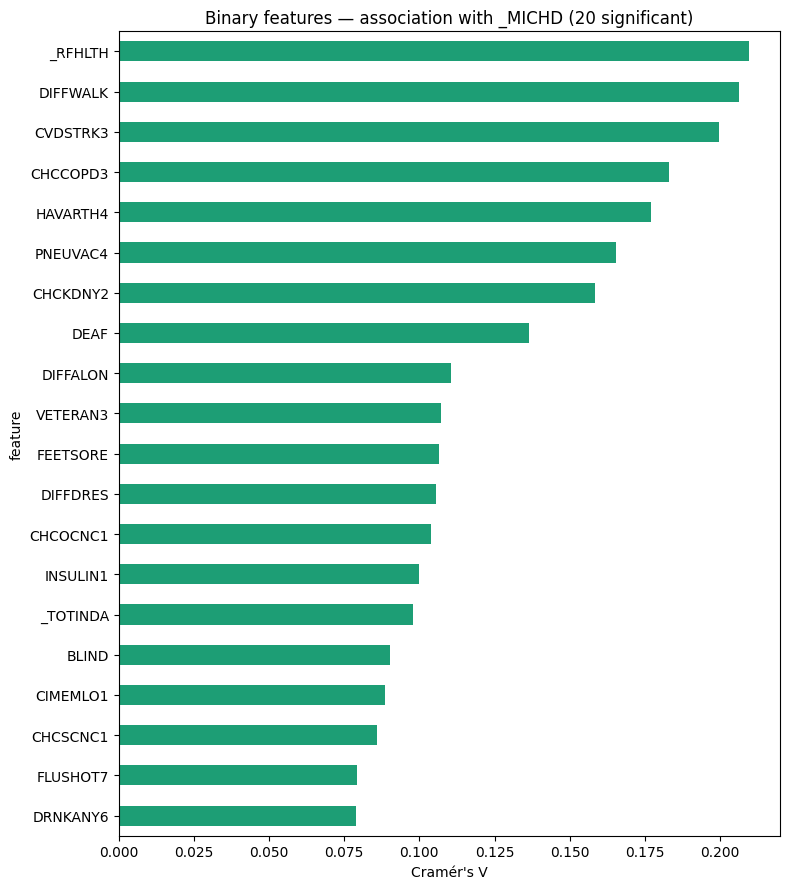

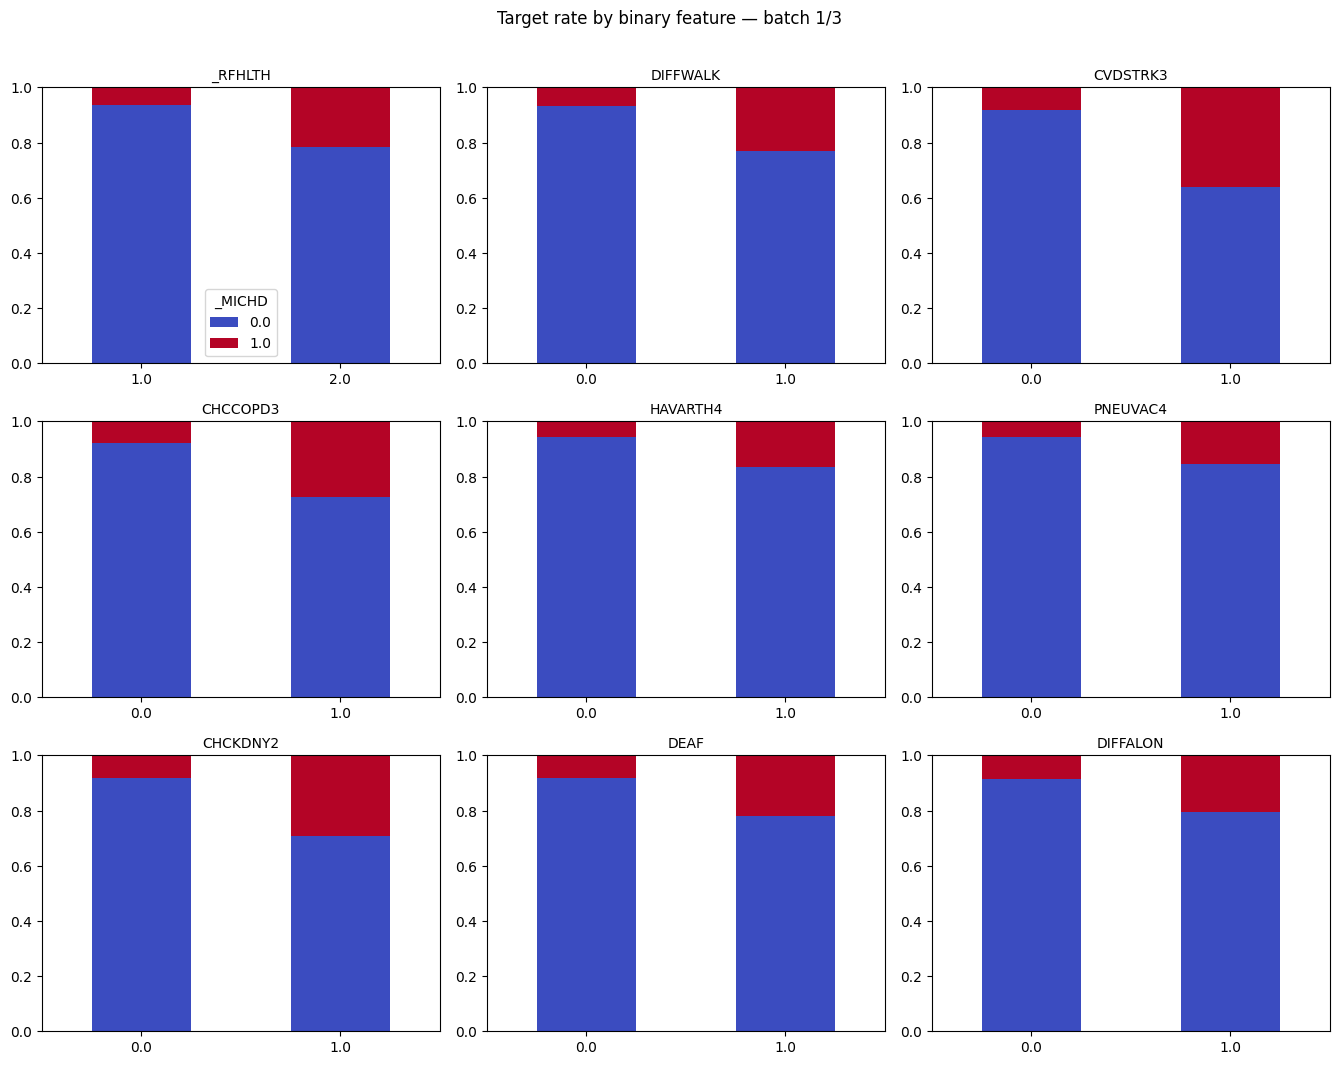

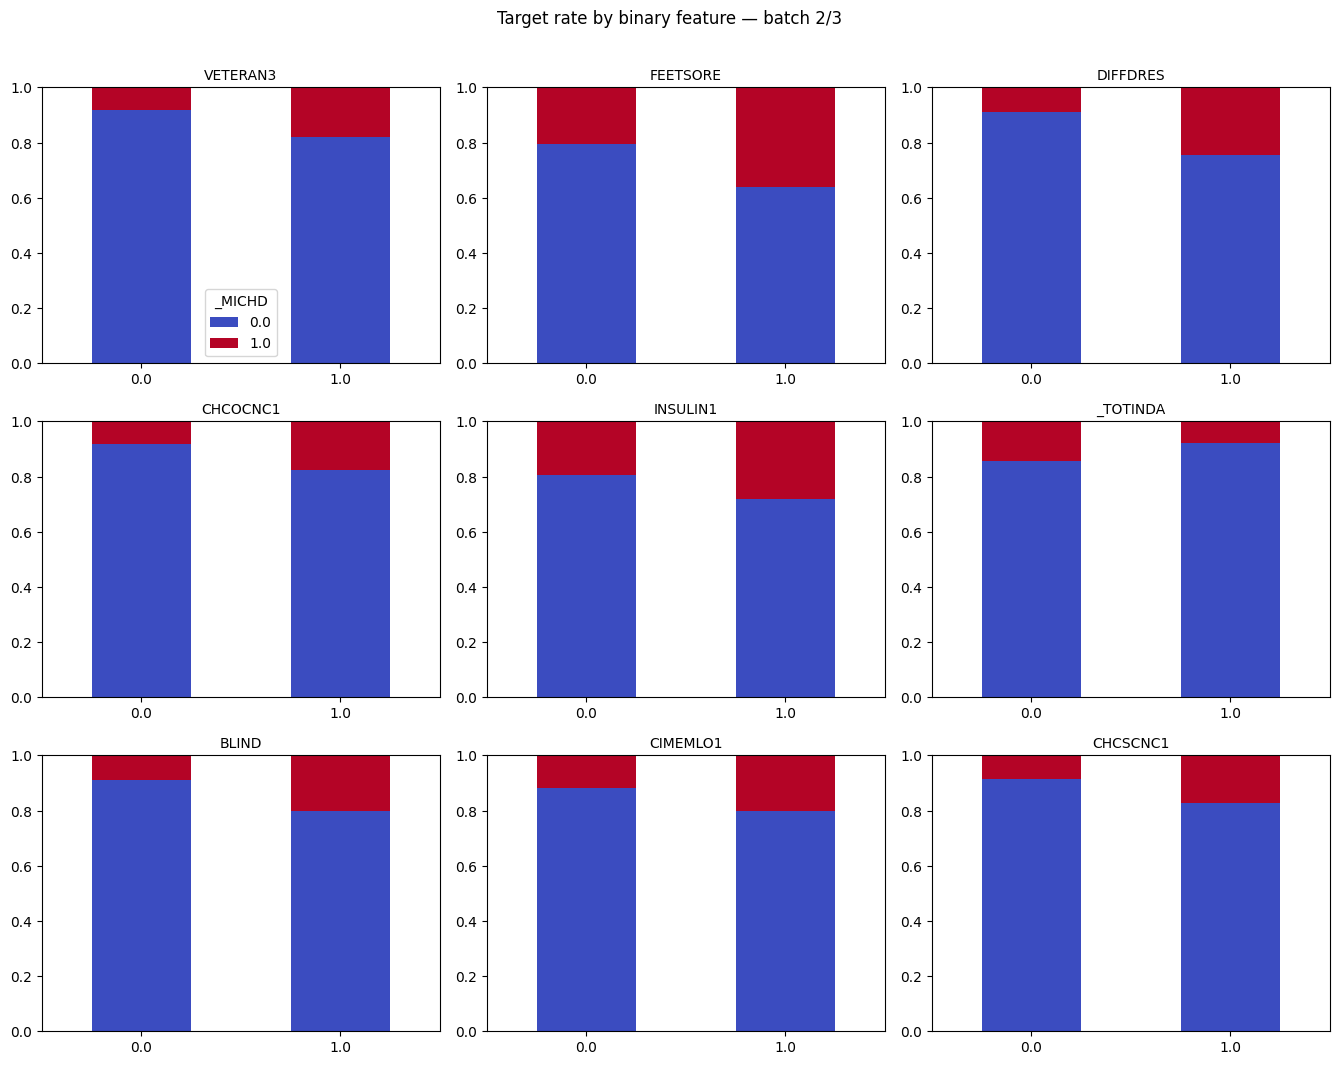

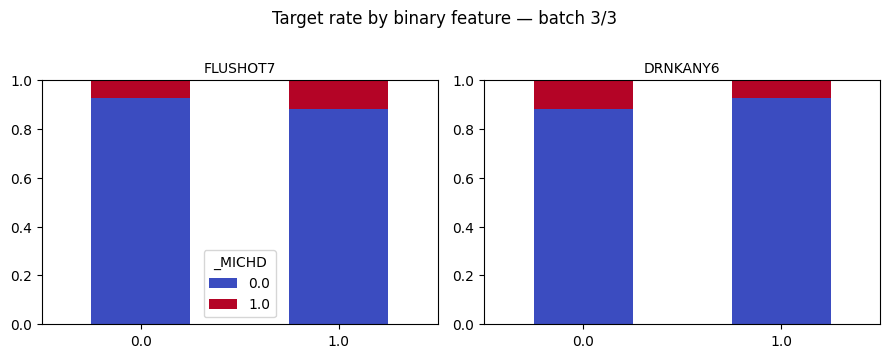

In [45]:
# Binary Features

bin_results = []
for col in binary_cols:
    clean = df[[col, TARGET]].dropna()
    ct    = pd.crosstab(clean[col], clean[TARGET])
    chi2, pval, _, _ = chi2_contingency(ct)
    cv    = cramers_v(clean[col], clean[TARGET])
    bin_results.append({"feature": col, "cramers_v": cv, "p_value": pval})

bin_df  = pd.DataFrame(bin_results).sort_values("cramers_v", ascending=False)
sig_bin = bin_df[bin_df["p_value"] < P_THRESHOLD].head(TOP_N)["feature"].tolist()

# ranking chart
fig, ax = plt.subplots(figsize=(8, max(3, len(sig_bin) * 0.4 + 1)))
(bin_df[bin_df["feature"].isin(sig_bin)]
 .set_index("feature")["cramers_v"]
 .sort_values()
 .plot(kind="barh", ax=ax, color="#1D9E75"))
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Cramér's V")
ax.set_title(f"Binary features — association with {TARGET} ({len(sig_bin)} significant)")
plt.tight_layout(); plt.show()

# stacked bar grids
def bin_plot_fn(col, j, ax):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax,
            colormap="coolwarm", legend=(j == 0), rot=0)
    ax.set_title(col, fontsize=10)
    ax.set_ylim(0, 1); ax.set_xlabel("")

plot_chunks(sig_bin, bin_plot_fn,
            "Target rate by binary feature — batch {}/{}")

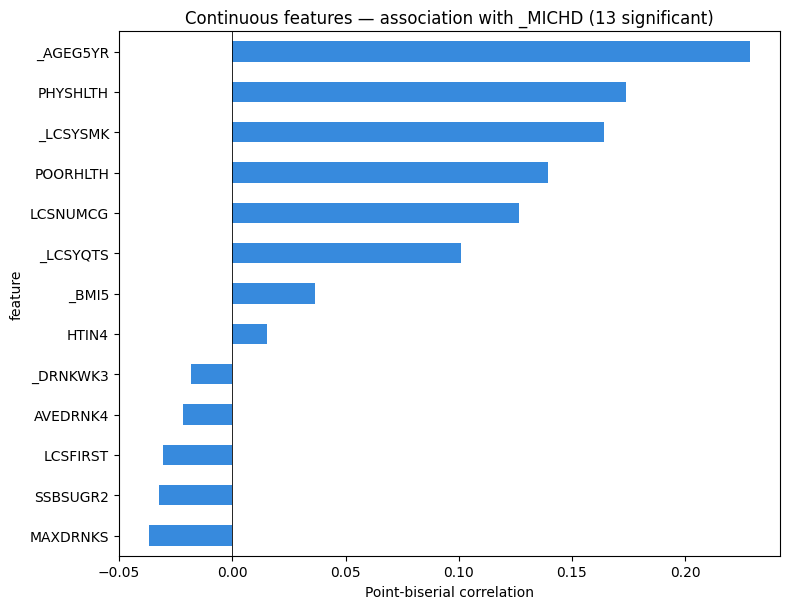

/tmp/ipykernel_38/4148251980.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap   = cm.get_cmap("tab10")
/tmp/ipykernel_38/4148251980.py:54: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=handles, fontsize=9)
/tmp/ipykernel_38/4148251980.py:54: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legen

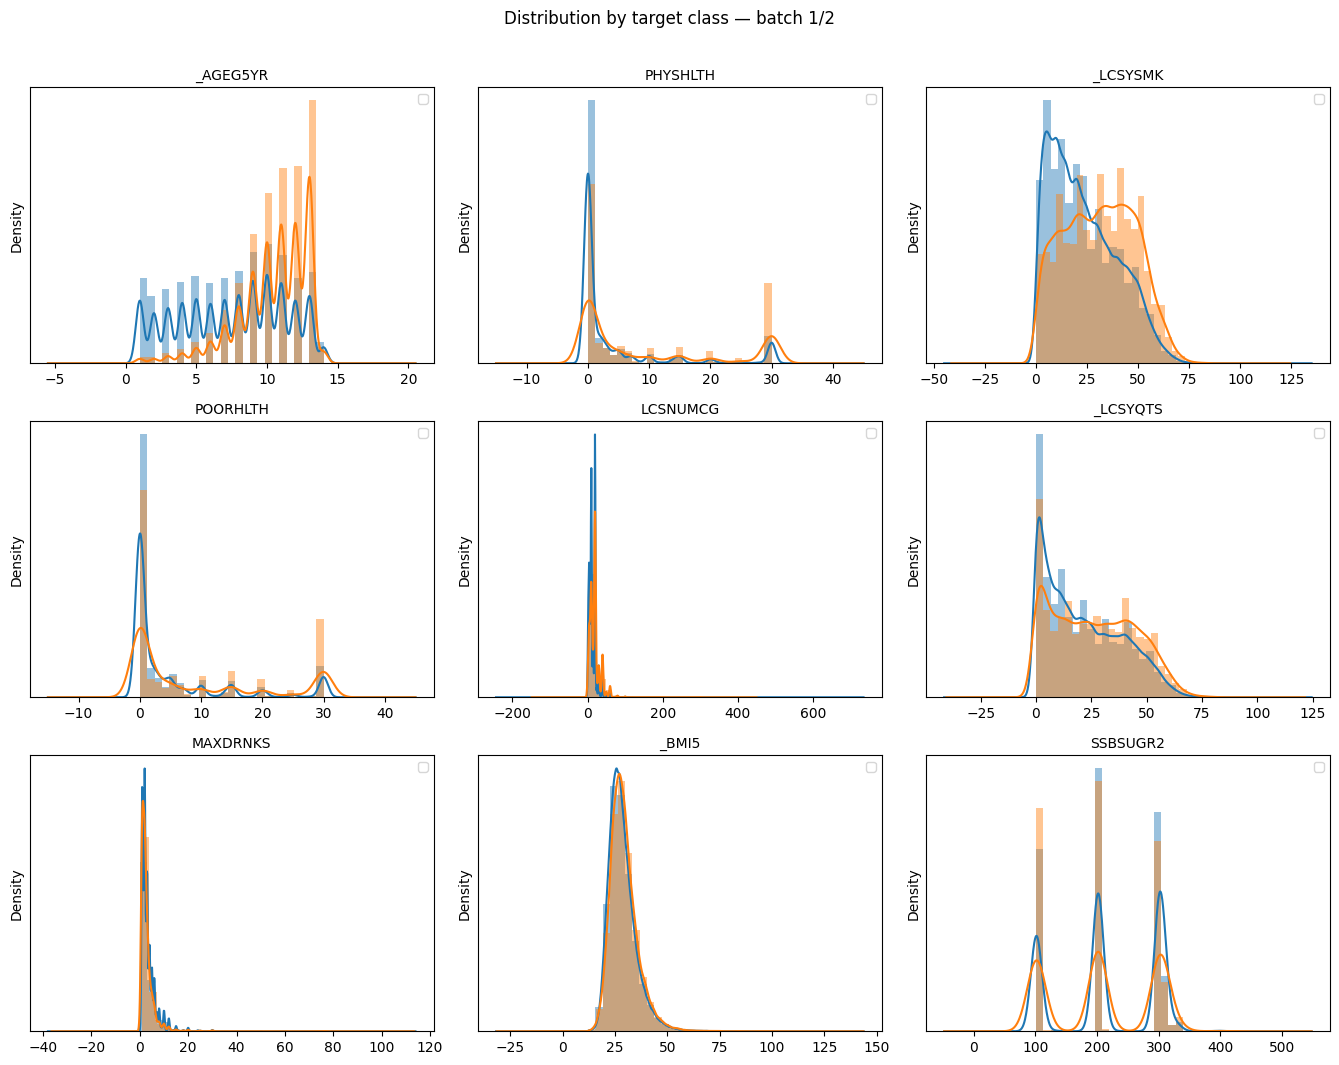

/tmp/ipykernel_38/4148251980.py:54: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=handles, fontsize=9)
/tmp/ipykernel_38/4148251980.py:54: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=handles, fontsize=9)
/tmp/ipykernel_38/4148251980.py:54: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists,

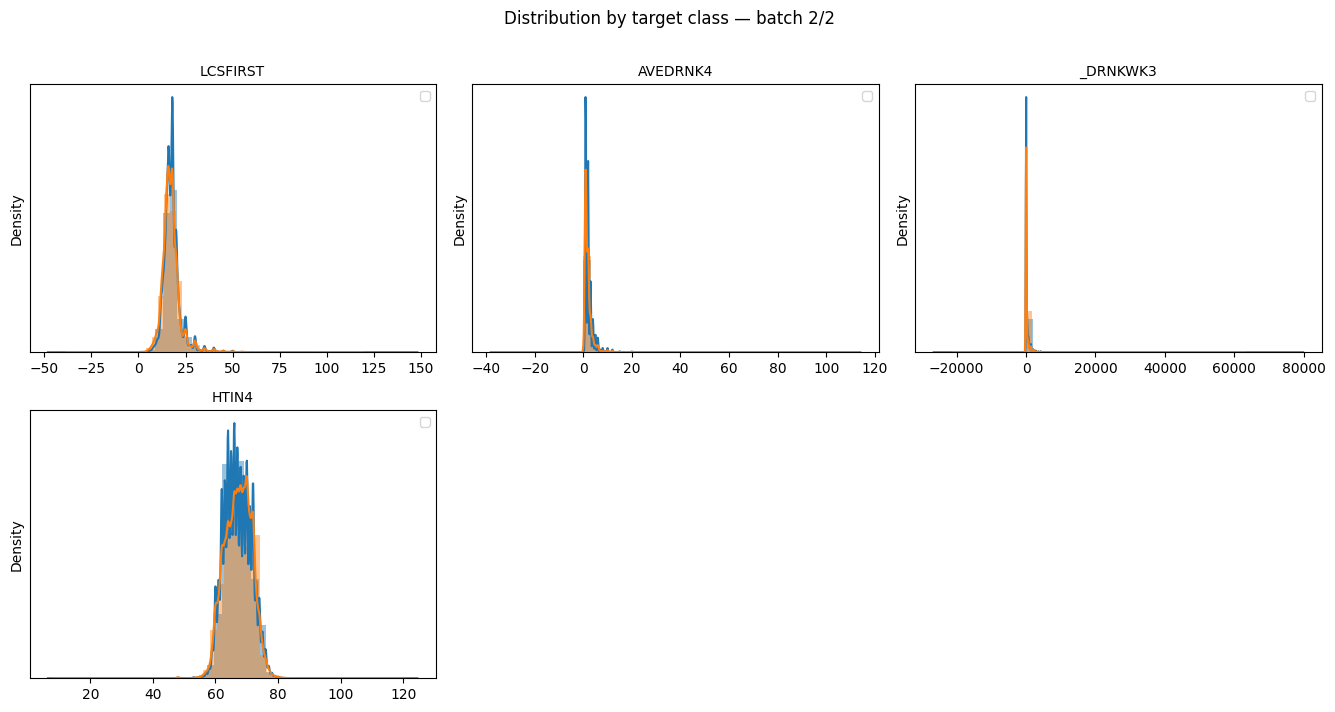

In [67]:
# Continuous Features

cont_results = []
for col in continuous_cols:
    clean = df[[col, TARGET]].dropna()
    corr, _ = pointbiserialr(clean[col], clean[TARGET])
    g0, g1  = clean[clean[TARGET]==0][col], clean[clean[TARGET]==1][col]
    _, pval = mannwhitneyu(g0, g1, alternative="two-sided")
    cont_results.append({"feature": col, "pb_corr": corr,
                         "abs_corr": abs(corr), "p_mw": pval})

cont_df  = pd.DataFrame(cont_results).sort_values("abs_corr", ascending=False)
sig_cont = cont_df[cont_df["p_mw"] < P_THRESHOLD].head(TOP_N)["feature"].tolist()

# ranking chart
fig, ax = plt.subplots(figsize=(8, max(3, len(sig_cont) * 0.4 + 1)))
(cont_df[cont_df["feature"].isin(sig_cont)]
 .set_index("feature")["pb_corr"]
 .sort_values()
 .plot(kind="barh", ax=ax, color="#378ADD"))
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Point-biserial correlation")
ax.set_title(f"Continuous features — association with {TARGET} ({len(sig_cont)} significant)")
plt.tight_layout(); plt.show()

# KDE overlay grids
classes = sorted(df[TARGET].unique())

# generate N colors from a colormap
cmap   = cm.get_cmap("tab10")
colors = [cmap(i) for i in range(len(classes))]

def cont_plot_fn(col, j, ax):
    for k, cls in enumerate(classes):
        subset = df[df[TARGET] == cls][col].dropna()
        
        if len(subset) < 2:
            continue
        
        ax.hist(subset, bins=25, alpha=0.45,
                color=colors[k], density=True)   # ← remove label here
        
        try:
            subset.plot.kde(ax=ax, color=colors[k], linewidth=1.5)
        except Exception:
            pass
    
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])
    
    # manually build legend with colored patches
    handles = [Patch(color=colors[k], alpha=0.6, label=f"{TARGET}={cls}")
               for k, cls in enumerate(classes)]
    ax.legend(handles=handles, fontsize=9)

plot_chunks(sig_cont, cont_plot_fn,
            "Distribution by target class — batch {}/{}")

In [61]:
classes

[0.0, 1.0, nan]

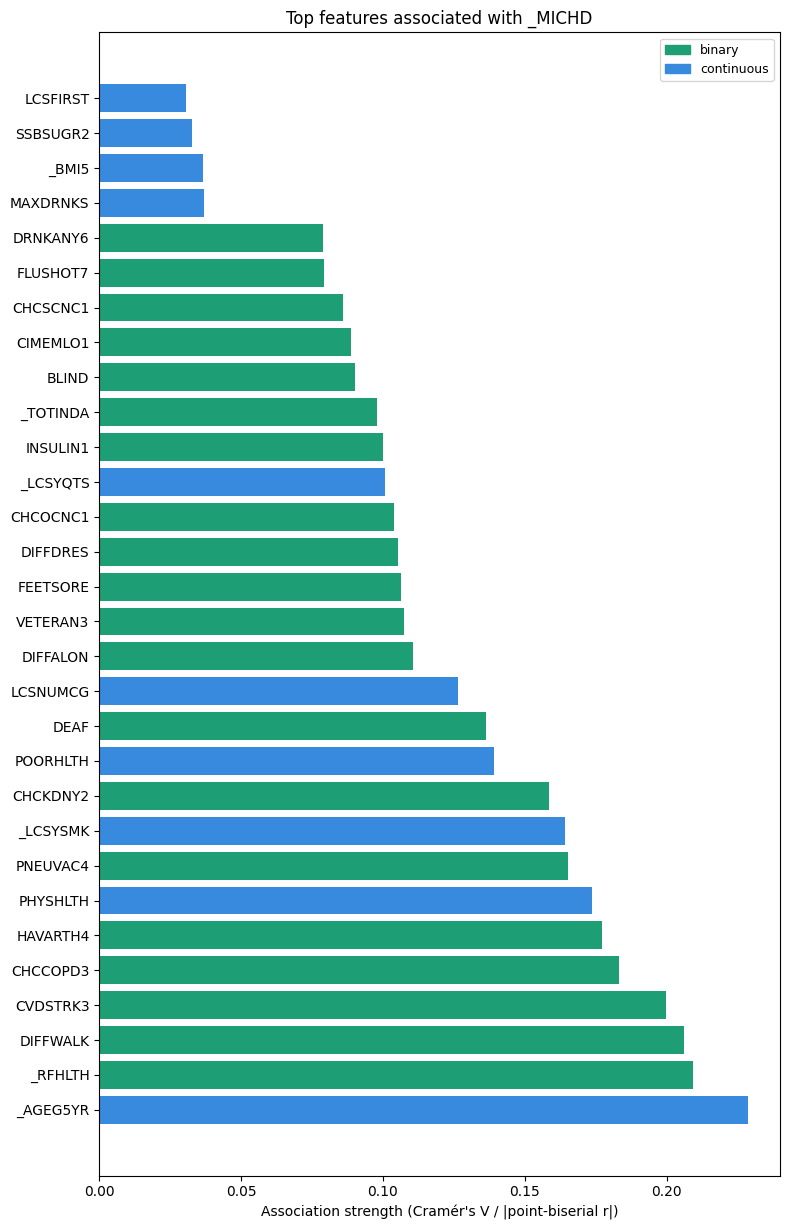

In [51]:
# Summary
bin_top = (bin_df[bin_df["feature"].isin(sig_bin)]
           [["feature","cramers_v"]]
           .rename(columns={"cramers_v":"score"})
           .assign(type="binary"))

cont_top = (cont_df[cont_df["feature"].isin(sig_cont)]
            [["feature","abs_corr"]]
            .rename(columns={"abs_corr":"score"})
            .assign(type="continuous"))

summary = (pd.concat([bin_top, cont_top])
           .sort_values("score", ascending=False)
           .head(30))

colors_map = {"binary": "#1D9E75", "continuous": "#378ADD"}
bar_colors = summary["type"].map(colors_map)

fig, ax = plt.subplots(figsize=(8, len(summary) * 0.38 + 1))
ax.barh(summary["feature"], summary["score"], color=bar_colors)
ax.set_xlabel("Association strength (Cramér's V / |point-biserial r|)")
ax.set_title(f"Top features associated with {TARGET}")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in colors_map.items()],
          fontsize=9)
plt.tight_layout(); plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88479c56-07bc-4e04-92b4-d8345dc226f4' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>